# Lab 5.1 — LLM Evaluation & Benchmarking: Measuring What Actually Matters
### Module 4: Large Language Models | Chitkara University B-Tech AI Specialization
---
**Duration:** 90 minutes | **Mode:** Individual | **Day 5 — Friday**

> **Scenario:** You are a Lead ML Engineer at an AI product studio called MindForge.
> MindForge is advising three enterprise clients — each wants to deploy an LLM
> for a different use case. Before recommending a model, you must evaluate
> several LLMs rigorously and explain your choice with data, not opinion.
>
> **Client A — EdTech (Textbook QA):** Needs factually accurate answers.
> Hallucinations are unacceptable. Accuracy on a subject-matter test set matters most.
>
> **Client B — Customer Support (Email writing):** Needs coherent, fluent responses.
> Grammar and tone matter. Speed matters for cost. Accuracy is secondary.
>
> **Client C — Legal Research (Document summarisation):** Needs summaries
> that faithfully cover the source without omitting key facts. No hallucination.
>
> You will build an evaluation harness, run automated metrics across all three
> task types, and write the recommendation report with supporting charts.

**Objective:** Implement five evaluation metrics (Exact Match, F1, ROUGE-L,
BERTScore, and a custom faithfulness scorer). Run a model comparison tournament.
Understand why perplexity is used for language models and compute it from scratch.
Build a radar chart evaluation dashboard and write a structured eval report.

---
### Runs entirely on Google Colab — no cloud credentials required

**Learning outcomes:**
- Distinguish intrinsic metrics (perplexity) from extrinsic task metrics (accuracy, ROUGE)
- Implement ROUGE-L, token-F1, and exact match from first principles
- Use BERTScore for semantic similarity evaluation
- Design evaluation test sets and explain why they must be held-out
- Compute and interpret perplexity as a measure of language model quality
- Build a multi-dimension radar chart comparison across models and tasks
- Write a structured model recommendation report grounded in metric evidence


## Background — The LLM Evaluation Landscape

### Why evaluation is hard for generative models

For classification tasks, accuracy is straightforward: correct or not.
For generative tasks, the same correct answer can be phrased dozens of ways.
'Paris is the capital of France' and 'France's capital city is Paris' are both
correct but would score 0 under exact match comparison.

### Metric categories

```
INTRINSIC METRICS (model quality, no task needed)
  Perplexity — how 'surprised' is the model by held-out text?
               Lower = better. Measures fluency and language understanding.
               PPL = exp(average negative log-likelihood per token)

REFERENCE-BASED METRICS (require a gold reference answer)
  Exact Match   — binary: does output == reference? (strictest)
  Token F1      — word overlap: harmonic mean of precision and recall
  ROUGE-L       — longest common subsequence overlap (order-aware)
  BERTScore     — semantic similarity via contextual embeddings (no word overlap needed)

REFERENCE-FREE METRICS (no gold answer needed)
  Faithfulness  — does the output contradict or hallucinate relative to source?
  Coherence     — is the text grammatically and logically consistent?
  G-Eval        — GPT-4 as judge (powerful but expensive)
```

### The evaluation trap: Goodhart's Law
*'When a measure becomes a target, it ceases to be a good measure.'*
A model can be optimised to score high on ROUGE without being actually useful.
Good eval uses **multiple complementary metrics** + human judgement.

### Key benchmarks you should know (AI-900 relevant)

| Benchmark | Task | What it tests |
|-----------|------|---------------|
| **MMLU** | Multi-choice QA | World knowledge across 57 subjects |
| **HumanEval** | Code generation | Functional correctness of code |
| **TruthfulQA** | QA | Resistance to common misconceptions |
| **HellaSwag** | Completion | Common-sense reasoning |
| **MT-Bench** | Multi-turn chat | Instruction following quality |


## Task 1 — Install packages and create the evaluation test sets

We create three test sets corresponding to MindForge's three clients.
Each has gold reference answers so we can compute objective metrics.

**Critical principle:** Test sets must be **held out** — never used during training
or prompt development. Using the test set to tune your prompt is 'test set leakage'
and invalidates the evaluation entirely.


In [11]:
!pip install rouge-score bert-score transformers torch nltk --quiet

import json, re, math, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
warnings.filterwarnings('ignore')

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

print('Packages ready.')


Packages ready.


In [12]:
# ══ TEST SET A — EdTech Factual QA (15 questions) ════════════════════════
# Format: (question, gold_answer)
# Gold answers are concise factual strings — suitable for Exact Match and F1.
testset_A_qa = [
    ('What does CPU stand for?',
     'Central Processing Unit'),
    ('What is the time complexity of binary search?',
     'O(log n)'),
    ('Who invented the World Wide Web?',
     'Tim Berners-Lee'),
    ('What does RAM stand for?',
     'Random Access Memory'),
    ('What is the binary representation of the decimal number 10?',
     '1010'),
    ('What does SQL stand for?',
     'Structured Query Language'),
    ('What is the output of 2 to the power of 8?',
     '256'),
    ('What is an IP address?',
     'A numerical label assigned to each device on a computer network'),
    ('What does HTTP stand for?',
     'HyperText Transfer Protocol'),
    ('What is a compiler?',
     'A program that translates source code into machine code'),
    ('What is the main function of an operating system?',
     'To manage hardware resources and provide services for computer programs'),
    ('What does GPU stand for?',
     'Graphics Processing Unit'),
    ('What is recursion in programming?',
     'A function that calls itself to solve a smaller instance of the same problem'),
    ('What is the difference between a stack and a queue?',
     'A stack is LIFO (last in first out) while a queue is FIFO (first in first out)'),
    ('What is an API?',
     'An Application Programming Interface that allows software systems to communicate'),
]

# ══ TEST SET B — Customer Support Email Quality (10 emails) ══════════════
# Format: (customer_complaint, gold_response)
# Gold responses are representative good-quality replies for ROUGE comparison.
testset_B_email = [
    (
        'My order has not arrived after 10 days. Order number ORD-8821.',
        'Thank you for reaching out about order ORD-8821. We sincerely apologise '
        'for the delay. Our team has escalated this to our logistics partner and '
        'will provide you with an updated tracking status within 24 hours. '
        'If the order does not arrive within 3 business days, we will arrange a '
        'full replacement at no additional cost. We value your patience.'
    ),
    (
        'I was charged twice for the same transaction on my credit card.',
        'We apologise for the duplicate charge on your account. Our billing team '
        'has been notified and will process a full refund of the duplicate amount '
        'within 5 to 7 business days. You will receive a confirmation email once '
        'the refund is initiated. Thank you for bringing this to our attention.'
    ),
    (
        'The product I received is damaged. The screen is cracked.',
        'We are very sorry to hear that your product arrived damaged. '
        'Please send us photographs of the damage and your order number '
        'so we can arrange an immediate replacement at no charge. '
        'A prepaid return label will be emailed to you within 2 hours.'
    ),
    (
        'I want to cancel my subscription but cannot find the option on the website.',
        'We understand you would like to cancel your subscription. '
        'You can do so by going to Account Settings > Subscriptions > Cancel Plan. '
        'If you continue to face difficulty, our support team is available 24/7 '
        'via chat to assist you directly. We hope to serve you again in the future.'
    ),
    (
        'I never received the invoice for my last purchase. I need it for tax purposes.',
        'Your invoice has been resent to your registered email address. '
        'Please also check your spam folder. If you need a GST invoice with '
        'specific details, please reply with your GSTIN and we will generate '
        'a compliant invoice within one business day.'
    ),
    (
        'The customer support agent I spoke to earlier was rude and unhelpful.',
        'We sincerely apologise for your experience with our support team. '
        'This falls well below the standard of service we hold ourselves to. '
        'Your feedback has been escalated to our quality team and will be '
        'reviewed within 48 hours. We would like to offer you a 20% discount '
        'on your next order as an apology.'
    ),
    (
        'My password reset email is not arriving. I have checked spam.',
        'We apologise for the inconvenience with the password reset. '
        'Please try using a different email provider or contact us via live chat '
        'so our team can verify your account and reset your password manually. '
        'We will resolve this within 15 minutes.'
    ),
    (
        'I was promised a delivery in 2 days but it has been 5 days. Very disappointed.',
        'We sincerely apologise that your order did not arrive within the promised timeframe. '
        'This is unacceptable and we take full responsibility. '
        'Your delivery has been upgraded to express shipping at no charge and '
        'you will receive a 15% discount voucher for your inconvenience.'
    ),
    (
        'Can I exchange a product I bought last week for a different colour?',
        'Yes, you can exchange your product within 30 days of purchase. '
        'Please visit our Returns and Exchanges page, select the colour you prefer, '
        'and we will ship the replacement once we receive the original item. '
        'Exchanges are free of charge with no restocking fee.'
    ),
    (
        'I accidentally placed the same order twice. Can you cancel one?',
        'Of course. We have cancelled the duplicate order and a full refund '
        'will be credited to your original payment method within 3 to 5 business days. '
        'Your remaining order is still on track for delivery as scheduled. '
        'We apologise for any confusion.'
    ),
]

# ══ TEST SET C — Legal Document Summarisation (8 passages) ═══════════════
# Format: (source_passage, gold_summary)
# Gold summaries are short faithful summaries for ROUGE + faithfulness scoring.
testset_C_legal = [
    (
        'The Vendor shall deliver the goods described in Schedule A within thirty (30) '
        'calendar days from the date of receipt of a valid purchase order. '
        'In the event of a delay exceeding seven (7) days beyond the agreed delivery date, '
        'the Purchaser shall be entitled to levy liquidated damages at the rate of '
        'one percent (1%) of the total contract value per week of delay, '
        'up to a maximum of ten percent (10%) of the contract value.',
        'Vendor must deliver within 30 days of purchase order. Delays over 7 days incur '
        '1% per week liquidated damages, capped at 10% of contract value.'
    ),
    (
        'Either party may terminate this Agreement upon ninety (90) days written notice '
        'to the other party without cause. Termination for cause, including material breach '
        'or insolvency, may be effected immediately upon written notice, subject to a '
        'cure period of fifteen (15) days for remediable breaches. '
        'Upon termination, all outstanding payments shall become immediately due and payable.',
        'Either party may terminate without cause on 90 days notice. Immediate termination '
        'is allowed for material breach, with a 15-day cure period. All payments become '
        'due immediately upon termination.'
    ),
    (
        'The Licensee is granted a non-exclusive, non-transferable, worldwide licence to '
        'use the Software solely for internal business purposes. '
        'The Licensee shall not sublicense, sell, resell, transfer, assign, or otherwise '
        'dispose of the Software or any rights therein. '
        'The Licensor retains all intellectual property rights in the Software.',
        'Licensee receives a non-exclusive worldwide licence for internal use only. '
        'Sublicensing, selling, or transferring the software is prohibited. '
        'Licensor retains all intellectual property rights.'
    ),
    (
        'Each party agrees to keep confidential all non-public information '
        'received from the other party and to use such information solely for '
        'the purposes of this Agreement. The confidentiality obligation shall survive '
        'termination of this Agreement for a period of three (3) years. '
        'Publicly available information and information independently developed '
        'are excluded from this obligation.',
        'Both parties must keep received non-public information confidential and use it '
        'only for this Agreement. Obligation survives termination for 3 years. '
        'Publicly available or independently developed information is excluded.'
    ),
    (
        'The total liability of either party under this Agreement shall not exceed '
        'the total fees paid by the Purchaser in the twelve (12) months preceding '
        'the event giving rise to the claim. '
        'Neither party shall be liable for indirect, consequential, incidental, '
        'special, or punitive damages, even if advised of the possibility of such damages.',
        'Total liability is capped at fees paid in the prior 12 months. '
        'Neither party is liable for indirect, consequential, or punitive damages.'
    ),
    (
        'The Contractor represents and warrants that all work product delivered under '
        'this Agreement shall be original, shall not infringe any third-party '
        'intellectual property rights, and shall be free from material defects '
        'for a period of ninety (90) days from delivery. '
        'The Contractor shall promptly remedy any defect reported within this warranty period.',
        'Contractor warrants deliverables are original, non-infringing, and defect-free '
        'for 90 days. Reported defects within this period must be promptly remedied.'
    ),
    (
        'This Agreement shall be governed by and construed in accordance with '
        'the laws of India, without regard to conflict of law principles. '
        'Any dispute arising out of or in connection with this Agreement shall be '
        'subject to the exclusive jurisdiction of the courts of New Delhi.',
        'Agreement is governed by Indian law. All disputes are subject to '
        'exclusive jurisdiction of New Delhi courts.'
    ),
    (
        'Neither party shall be liable for failure or delay in performing obligations '
        'under this Agreement if such failure or delay is caused by circumstances '
        'beyond reasonable control, including acts of God, natural disasters, '
        'war, strikes, or government actions. '
        'The affected party must notify the other party in writing within five (5) days '
        'of the force majeure event.',
        'Neither party is liable for force majeure delays beyond their control, '
        'including natural disasters, war, or government actions. '
        'Affected party must provide written notice within 5 days.'
    ),
]

print(f'Test Set A (EdTech QA)          : {len(testset_A_qa)} questions')
print(f'Test Set B (Customer Support)   : {len(testset_B_email)} emails')
print(f'Test Set C (Legal Summaries)    : {len(testset_C_legal)} passages')
print(f'Total evaluation examples       : {len(testset_A_qa)+len(testset_B_email)+len(testset_C_legal)}')


Test Set A (EdTech QA)          : 15 questions
Test Set B (Customer Support)   : 10 emails
Test Set C (Legal Summaries)    : 8 passages
Total evaluation examples       : 33


## Task 2 — Implement evaluation metrics from scratch

We implement five metrics. Understanding them from code (not just using a library)
is essential for knowing when they are appropriate and when they mislead.

### Exact Match
Binary: 1 if prediction == reference (after normalisation), else 0.
Used for factoid QA where the answer is a fixed short string.

### Token F1
Compute precision and recall at the **token (word) level**:
- Precision = shared_tokens / prediction_tokens
- Recall = shared_tokens / reference_tokens
- F1 = 2 × (P × R) / (P + R)

### ROUGE-L (Recall-Oriented Understudy for Gisting Evaluation)
Uses the **longest common subsequence** (LCS) between prediction and reference.
LCS is order-aware but not contiguous — it respects sentence structure better than
simple n-gram overlap.

### BERTScore
Computes similarity using contextual BERT embeddings. Two tokens can have high
BERTScore even if they are different words — e.g. 'car' and 'automobile'.
Captures semantic similarity that n-gram metrics miss entirely.

### Faithfulness Score (custom)
For summarisation: what fraction of key content words in the gold summary
also appear in the model's output? Penalises omission of key facts.


In [13]:
# ══ METRIC 1: Exact Match ════════════════════════════════════════════════
def normalise(text):
    """Lowercase, strip punctuation, collapse whitespace."""
    text = text.lower().strip()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text

def exact_match(prediction, reference):
    """Return 1.0 if normalised strings match exactly, else 0.0."""
    return float(normalise(prediction) == normalise(reference))

# ══ METRIC 2: Token F1 ═══════════════════════════════════════════════════
def token_f1(prediction, reference):
    """
    Token-level F1 score.
    Tokenise both strings; compute precision, recall, F1 over token bags.
    """
    pred_tokens = normalise(prediction).split()
    ref_tokens  = normalise(reference).split()
    if not pred_tokens or not ref_tokens:
        return 0.0, 0.0, 0.0
    pred_counter = Counter(pred_tokens)
    ref_counter  = Counter(ref_tokens)
    # Shared tokens (intersection counts)
    shared = sum((pred_counter & ref_counter).values())
    if shared == 0:
        return 0.0, 0.0, 0.0
    precision = shared / len(pred_tokens)
    recall    = shared / len(ref_tokens)
    f1        = 2 * precision * recall / (precision + recall)
    return round(precision, 4), round(recall, 4), round(f1, 4)

# ══ METRIC 3: ROUGE-L ════════════════════════════════════════════════════
def lcs_length(x, y):
    """Compute length of Longest Common Subsequence between token lists x and y."""
    m, n = len(x), len(y)
    # Use space-efficient two-row DP
    prev = [0] * (n + 1)
    curr = [0] * (n + 1)
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if x[i-1] == y[j-1]:
                curr[j] = prev[j-1] + 1
            else:
                curr[j] = max(curr[j-1], prev[j])
        prev, curr = curr, [0] * (n + 1)
    return prev[n]

def rouge_l(prediction, reference):
    """
    ROUGE-L: F1 score based on Longest Common Subsequence.
    Returns (precision, recall, f1).
    """
    pred_tokens = normalise(prediction).split()
    ref_tokens  = normalise(reference).split()
    if not pred_tokens or not ref_tokens:
        return 0.0, 0.0, 0.0
    lcs = lcs_length(pred_tokens, ref_tokens)
    if lcs == 0:
        return 0.0, 0.0, 0.0
    precision = lcs / len(pred_tokens)
    recall    = lcs / len(ref_tokens)
    f1        = 2 * precision * recall / (precision + recall)
    return round(precision, 4), round(recall, 4), round(f1, 4)

# ══ METRIC 4: Faithfulness (custom for summarisation) ════════════════════
STOPWORDS = {'the','a','an','is','are','was','were','be','been','being',
             'have','has','had','do','does','did','will','would','shall',
             'should','may','might','must','can','could','to','of','in',
             'for','on','with','at','by','from','and','or','but','not',
             'it','its','this','that','these','those','all','any','both'}

def faithfulness_score(prediction, reference):
    """
    Fraction of content words in reference that appear in prediction.
    Content words = non-stopword tokens in the gold reference.
    Measures whether the key facts from the source made it into the summary.
    """
    pred_words = set(normalise(prediction).split())
    ref_words  = [w for w in normalise(reference).split() if w not in STOPWORDS]
    if not ref_words:
        return 1.0
    covered = sum(1 for w in ref_words if w in pred_words)
    return round(covered / len(ref_words), 4)

# ══ VERIFY ALL METRICS on a known pair ═══════════════════════════════════
pred_ex = 'The CPU stands for Central Processing Unit in computers'
ref_ex  = 'Central Processing Unit'

print('METRIC VERIFICATION')
print('=' * 55)
print(f'  Prediction : "{pred_ex}"')
print(f'  Reference  : "{ref_ex}"')
print()
print(f'  Exact Match : {exact_match(pred_ex, ref_ex):.4f}  (0=no match, 1=perfect)')
p,r,f = token_f1(pred_ex, ref_ex)
print(f'  Token F1    : P={p:.4f}  R={r:.4f}  F1={f:.4f}')
p,r,f = rouge_l(pred_ex, ref_ex)
print(f'  ROUGE-L     : P={p:.4f}  R={r:.4f}  F1={f:.4f}')
print(f'  Faithfulness: {faithfulness_score(pred_ex, ref_ex):.4f}')
print()
print('Note: EM=0 even though the answer is semantically correct.')
print('This is exactly why we use multiple complementary metrics.')


METRIC VERIFICATION
  Prediction : "The CPU stands for Central Processing Unit in computers"
  Reference  : "Central Processing Unit"

  Exact Match : 0.0000  (0=no match, 1=perfect)
  Token F1    : P=0.3333  R=1.0000  F1=0.5000
  ROUGE-L     : P=0.3333  R=1.0000  F1=0.5000
  Faithfulness: 1.0000

Note: EM=0 even though the answer is semantically correct.
This is exactly why we use multiple complementary metrics.


In [14]:
# ══ METRIC 5: BERTScore ══════════════════════════════════════════════════
# BERTScore uses contextual BERT embeddings to compute semantic similarity.
# We use distilbert which is fast enough for Colab.
from bert_score import score as bert_score_fn

def compute_bertscore_batch(predictions, references, model_type='distilbert-base-uncased'):
    """
    Compute BERTScore F1 for a list of (prediction, reference) pairs.
    Returns a list of F1 scores (floats).
    """
    print(f'  Computing BERTScore for {len(predictions)} pairs...')
    P, R, F1 = bert_score_fn(
        predictions, references,
        model_type=model_type,
        lang='en',
        verbose=False,
        device='cpu',
    )
    return [round(float(f), 4) for f in F1]

# Quick BERTScore test
test_preds = [
    'Central Processing Unit',          # near-exact match
    'The brain of the computer chip',   # semantically related but different words
    'A type of storage device for data',# wrong concept
]
test_refs = ['Central Processing Unit'] * 3

print('BERTScore test (downloading DistilBERT ~265MB on first run):')
bs_scores = compute_bertscore_batch(test_preds, test_refs)
for pred, score in zip(test_preds, bs_scores):
    print(f'  {score:.4f}  "{pred}"')
print()
print('Note: Semantic relatedness ("brain of computer") scores higher than')
print('a factually wrong answer — this is what BERTScore captures over ROUGE.')


BERTScore test (downloading DistilBERT ~265MB on first run):
  Computing BERTScore for 3 pairs...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  1.0000  "Central Processing Unit"
  0.7375  "The brain of the computer chip"
  0.7258  "A type of storage device for data"

Note: Semantic relatedness ("brain of computer") scores higher than
a factually wrong answer — this is what BERTScore captures over ROUGE.


## Task 3 — Simulate model outputs and run the full evaluation tournament

We simulate four models at different quality levels on each test set.
In a real evaluation you would send each test input through each model's API.
Here, we construct realistic outputs that match known quality differences,
so the metrics produce interpretable results you can reason about.

**Four models being compared:**
- **ModelA (GPT-3.5 class):** High accuracy, good summarisation, decent email
- **ModelB (Mistral-7B class):** Good accuracy, strong summarisation, slightly verbose
- **ModelC (Small BERT-based):** Weaker on generation, good on extraction tasks
- **ModelD (Weak baseline):** Keyword retrieval, no generation quality

The goal: find which model is best for *each client's specific use case*.


In [15]:
# ══ Simulated model outputs — Task A (QA) ════════════════════════════════
# Each model's answers to the 15 QA questions
# Real variation: some models give exact answers, some add explanation, some are wrong

model_outputs_A = {
    'ModelA': [
        'Central Processing Unit',
        'O(log n)',
        'Tim Berners-Lee invented the World Wide Web',
        'Random Access Memory',
        '1010',
        'Structured Query Language',
        '256',
        'A unique numerical address assigned to devices on a network for identification',
        'HyperText Transfer Protocol',
        'A program that converts high-level source code into executable machine code',
        'To manage computer hardware resources and provide services to application programs',
        'Graphics Processing Unit',
        'A programming technique where a function calls itself to solve subproblems',
        'A stack follows LIFO while a queue follows FIFO ordering',
        'Application Programming Interface — a set of rules for software communication',
    ],
    'ModelB': [
        'CPU stands for Central Processing Unit, the main processor in a computer',
        'The time complexity of binary search is O(log n) in both best and average case',
        'Tim Berners-Lee',
        'RAM is Random Access Memory, used for temporary data storage',
        '1010 in binary',
        'SQL stands for Structured Query Language used for database management',
        'Two to the power of 8 equals 256',
        'An IP address identifies a device on a network using a numeric label',
        'HyperText Transfer Protocol is used for web communication',
        'A compiler translates source code into machine code or bytecode',
        'An OS manages hardware and provides an interface for running applications',
        'GPU is Graphics Processing Unit, specialised for parallel computation',
        'Recursion is when a function calls itself until a base case is reached',
        'Stack is LIFO, queue is FIFO',
        'API is an interface allowing different software systems to interact',
    ],
    'ModelC': [
        'CPU - Central Processing',           # truncated
        'O(n log n)',                          # WRONG — this is merge sort
        'Tim Berners-Lee created the web in 1989',
        'RAM Random Access Memory volatile',
        '10',                                  # WRONG
        'SQL Structured Query Language databases',
        '512',                                 # WRONG
        'IP address is a network address number',
        'HTTP HyperText Transfer',
        'Compiler converts code',
        'OS manages hardware',
        'GPU graphics processor',
        'Recursion function calls itself',
        'Stack LIFO queue FIFO both data structures',
        'API programming interface',
    ],
    'ModelD': [
        'CPU processor computer',              # keyword dump
        'search algorithm complexity',
        'web inventor person',
        'RAM memory computer chip',
        'binary number system',
        'SQL database language query',
        'power mathematics number',
        'IP network address device',
        'HTTP web protocol internet',
        'compiler code program language',
        'operating system hardware management',
        'GPU graphics card visual',
        'recursion programming concept',
        'data structures differences',
        'API software interface',
    ],
}

# ══ Simulated model outputs — Task B (Email) ═════════════════════════════
model_outputs_B = {
    'ModelA': [
        'Thank you for contacting us about order ORD-8821. We apologise for the delay '
        'and have escalated this to our logistics team. You will receive a tracking update '
        'within 24 hours. If unresolved in 3 days we will send a replacement.',
        'We are sorry for the duplicate charge. Our billing team will process a full refund '
        'within 5-7 business days. You will receive a confirmation email shortly.',
        'We apologise for the damaged product. Please send photos of the damage with your '
        'order number and we will send a replacement immediately with a prepaid return label.',
        'To cancel your subscription go to Account Settings then Subscriptions then Cancel Plan. '
        'Our 24/7 chat support can also assist you directly if needed.',
        'Your invoice has been resent. Please check your spam folder. '
        'Reply with your GSTIN if you need a tax invoice.',
        'We sincerely apologise for your poor experience. This has been escalated to our '
        'quality team and you will receive a 20% discount on your next purchase as an apology.',
        'We apologise for the password reset issue. Please contact our live chat support '
        'and we will reset your account manually within 15 minutes.',
        'We are very sorry about the delivery delay. Your order has been upgraded to express '
        'shipping and you will receive a 15% discount voucher for the inconvenience.',
        'Yes you can exchange within 30 days for free. Visit our Returns page, select your '
        'preferred colour and we will ship once the original item is received.',
        'We have cancelled the duplicate order. A full refund will be credited within '
        '3-5 business days. Your remaining order is on schedule.',
    ],
    'ModelB': [
        'Hello, thank you for reaching out. I understand your order ORD-8821 has not arrived '
        'after 10 days and I can see how frustrating this must be. I have personally escalated '
        'this to our delivery partner and will ensure you receive a status update within the '
        'next 24 hours. Should your order remain undelivered after three business days, '
        'we will dispatch a full replacement at our expense. Thank you for your patience.',
        'Dear customer, I sincerely apologise for the double charge on your account. '
        'This is clearly an error on our part. Our finance team has been notified and '
        'will process the refund within 5 to 7 working days to your original payment method.',
        'I am so sorry to hear your item arrived damaged. We take full responsibility. '
        'Please reply with your order number and photos and we will send a replacement today.',
        'I understand you would like to cancel. Please go to Account Settings and Subscriptions. '
        'Our live chat is also available around the clock to guide you through this.',
        'Your invoice has been resent to your email. Please also check spam. '
        'We can generate a GST invoice if you provide your GSTIN number.',
        'I am deeply sorry for this experience. Your feedback is important and has been '
        'flagged for immediate review. We would like to offer a discount as an apology.',
        'We apologise for the inconvenience. Please use our live chat for a manual reset.',
        'I apologise sincerely for not meeting the promised delivery date. '
        'We are upgrading your shipment and adding a 15% voucher immediately.',
        'Absolutely, exchanges within 30 days are free of charge on our platform.',
        'Done — the duplicate has been cancelled. Refund in 3-5 days. Main order is safe.',
    ],
    'ModelC': [
        'Order delay. Contact logistics. Wait 24 hours.',
        'Duplicate charge refund 5 days.',
        'Damaged product return label photos.',
        'Cancel account settings subscriptions.',
        'Invoice sent check spam.',
        'Agent complaint escalated.',
        'Password reset contact support.',
        'Delivery delay express shipping.',
        'Exchange 30 days free.',
        'Duplicate order cancelled refund.',
    ],
    'ModelD': [
        'order delivery wait customer',
        'charge refund billing payment',
        'product damaged return',
        'subscription cancel account',
        'invoice email tax',
        'agent rude complaint quality',
        'password reset email',
        'delivery late express',
        'exchange return colour',
        'duplicate cancel refund',
    ],
}

# ══ Simulated model outputs — Task C (Legal summarisation) ════════════════
model_outputs_C = {
    'ModelA': [
        'Vendor must deliver within 30 days of receiving a purchase order. '
        'Delays over 7 days result in 1% per week damages, capped at 10% of contract value.',
        'Either party can terminate without cause with 90 days notice. '
        'Immediate termination is available for material breach with a 15-day cure period. '
        'Outstanding payments become due immediately on termination.',
        'Licensee gets a non-exclusive worldwide licence for internal use only. '
        'The software cannot be sublicensed or transferred. Licensor retains all IP rights.',
        'Parties must keep non-public information confidential for 3 years after termination. '
        'Public or independently developed information is excluded from this obligation.',
        'Total liability is capped at fees paid in the previous 12 months. '
        'Indirect and punitive damages are excluded.',
        'Deliverables must be original and non-infringing, with a 90-day defect warranty. '
        'Defects reported within this period must be corrected promptly.',
        'Indian law governs the agreement. New Delhi courts have exclusive jurisdiction.',
        'Neither party is liable for force majeure events. '
        'Affected party must notify in writing within 5 days.',
    ],
    'ModelB': [
        'The vendor is required to deliver goods within 30 calendar days. '
        'A penalty of 1% per week applies for delays beyond 7 days, with a 10% cap.',
        'Termination without cause requires 90 days written notice. '
        'Immediate termination for cause includes a 15-day cure period for fixable breaches. '
        'All payments accelerate upon termination.',
        'A non-exclusive non-transferable licence is granted for internal use. '
        'Sublicensing and resale are prohibited. All IP remains with the licensor.',
        'Both parties owe 3-year post-termination confidentiality for non-public information. '
        'Public knowledge and independently created information are exempt.',
        'Liability is limited to 12 months of fees paid. '
        'Consequential and punitive damages are excluded by both parties.',
        'Work must be original with no IP infringement, warranted defect-free for 90 days. '
        'Contractor must fix reported defects during the warranty period.',
        'The agreement is governed by Indian law with New Delhi having exclusive jurisdiction.',
        'Force majeure events excuse performance. '
        'The affected party must give written notice within 5 days of the event.',
    ],
    'ModelC': [
        'Vendor deliver 30 days purchase order liquidated damages 1 percent 10 percent',
        'Terminate 90 days notice material breach cure period payments due',
        'Non-exclusive licence internal use sublicense prohibited IP rights licensor',
        'Confidential information 3 years public information excluded',
        'Liability capped 12 months fees indirect damages excluded',
        'Deliverables original non-infringing 90 day warranty defects remedy',
        'Indian law New Delhi courts jurisdiction',
        'Force majeure liability written notice 5 days',
    ],
    'ModelD': [
        'delivery goods contract vendor purchaser',
        'termination agreement parties notice breach',
        'licence software use rights',
        'confidential information parties agreement',
        'liability damages fees payment',
        'warranty defects contractor deliverables',
        'law courts jurisdiction India',
        'force majeure performance notice',
    ],
}

print('All simulated model outputs ready.')
print(f'  Models: {list(model_outputs_A.keys())}')
print(f'  Task A outputs per model: {len(model_outputs_A["ModelA"])}')
print(f'  Task B outputs per model: {len(model_outputs_B["ModelA"])}')
print(f'  Task C outputs per model: {len(model_outputs_C["ModelA"])}')


All simulated model outputs ready.
  Models: ['ModelA', 'ModelB', 'ModelC', 'ModelD']
  Task A outputs per model: 15
  Task B outputs per model: 10
  Task C outputs per model: 8


In [16]:
# ══ Run full evaluation across all models and tasks ═══════════════════════
MODELS = ['ModelA', 'ModelB', 'ModelC', 'ModelD']

# ── Task A evaluation (Exact Match + Token F1 + BERTScore) ────────────────
print('Evaluating Task A (QA)...')
results_A = {}
for model in MODELS:
    preds = model_outputs_A[model]
    refs  = [r for _, r in testset_A_qa]
    em_scores    = [exact_match(p, r) for p, r in zip(preds, refs)]
    f1_scores    = [token_f1(p, r)[2] for p, r in zip(preds, refs)]
    rouge_scores = [rouge_l(p, r)[2] for p, r in zip(preds, refs)]
    results_A[model] = {
        'exact_match': round(np.mean(em_scores), 4),
        'token_f1'   : round(np.mean(f1_scores), 4),
        'rouge_l'    : round(np.mean(rouge_scores), 4),
    }
    print(f'  {model}: EM={results_A[model]["exact_match"]:.3f}  F1={results_A[model]["token_f1"]:.3f}  ROUGE-L={results_A[model]["rouge_l"]:.3f}')

print('\nEvaluating Task A BERTScore (this takes ~1 minute)...')
for model in MODELS:
    preds = model_outputs_A[model]
    refs  = [r for _, r in testset_A_qa]
    bs = compute_bertscore_batch(preds, refs)
    results_A[model]['bertscore'] = round(np.mean(bs), 4)
    print(f'  {model} BERTScore: {results_A[model]["bertscore"]:.3f}')

# ── Task B evaluation (ROUGE-L + BERTScore; EM not appropriate for long emails) ─
print('\nEvaluating Task B (Email)...')
results_B = {}
for model in MODELS:
    preds = model_outputs_B[model]
    refs  = [r for _, r in testset_B_email]
    rouge_scores = [rouge_l(p, r)[2] for p, r in zip(preds, refs)]
    results_B[model] = {
        'rouge_l': round(np.mean(rouge_scores), 4),
    }
print('Computing Task B BERTScore...')
for model in MODELS:
    preds = model_outputs_B[model]
    refs  = [r for _, r in testset_B_email]
    bs    = compute_bertscore_batch(preds, refs)
    results_B[model]['bertscore'] = round(np.mean(bs), 4)
    avg_len = np.mean([len(p.split()) for p in preds])
    results_B[model]['avg_length'] = round(avg_len, 1)
    print(f'  {model}: ROUGE-L={results_B[model]["rouge_l"]:.3f}  BERTScore={results_B[model]["bertscore"]:.3f}  avg_len={avg_len:.0f}w')

# ── Task C evaluation (ROUGE-L + BERTScore + Faithfulness) ────────────────
print('\nEvaluating Task C (Legal Summarisation)...')
results_C = {}
for model in MODELS:
    preds = model_outputs_C[model]
    refs  = [r for _, r in testset_C_legal]
    rouge_scores = [rouge_l(p, r)[2] for p, r in zip(preds, refs)]
    faith_scores = [faithfulness_score(p, r) for p, r in zip(preds, refs)]
    results_C[model] = {
        'rouge_l'    : round(np.mean(rouge_scores), 4),
        'faithfulness': round(np.mean(faith_scores), 4),
    }
print('Computing Task C BERTScore...')
for model in MODELS:
    preds = model_outputs_C[model]
    refs  = [r for _, r in testset_C_legal]
    bs    = compute_bertscore_batch(preds, refs)
    results_C[model]['bertscore'] = round(np.mean(bs), 4)
    print(f'  {model}: ROUGE-L={results_C[model]["rouge_l"]:.3f}  BERTScore={results_C[model]["bertscore"]:.3f}  Faith={results_C[model]["faithfulness"]:.3f}')

print('\nAll evaluations complete!')


Evaluating Task A (QA)...
  ModelA: EM=0.533  F1=0.813  ROUGE-L=0.801
  ModelB: EM=0.067  F1=0.483  ROUGE-L=0.477
  ModelC: EM=0.000  F1=0.368  ROUGE-L=0.368
  ModelD: EM=0.000  F1=0.164  ROUGE-L=0.115

Evaluating Task A BERTScore (this takes ~1 minute)...
  Computing BERTScore for 15 pairs...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  ModelA BERTScore: 0.950
  Computing BERTScore for 15 pairs...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  ModelC: ROUGE-L=0.398  BERTScore=0.834  Faith=0.412
  Computing BERTScore for 8 pairs...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  ModelD: ROUGE-L=0.153  BERTScore=0.782  Faith=0.196

All evaluations complete!


## Task 4 — Compute perplexity from scratch

**Perplexity** is the most fundamental *intrinsic* metric for language models.
It does not require a task or reference answers — it measures how well the model
predicts held-out text by computing the model's average surprise per token.

```
PPL = exp( -1/N × Σ log P(token_i | token_1..i-1) )
```

- **Low perplexity:** The model assigns high probability to the actual next tokens.
  The model 'expects' the text — it fits the distribution well.
- **High perplexity:** The model is frequently surprised. Poor language model.

**Typical values:**
- GPT-2 on web text: ~30 perplexity
- GPT-3 on web text: ~20 perplexity
- GPT-4 on web text: ~5–10 perplexity
- Random character model: ~65 perplexity (for English)

We compute perplexity for GPT-2 on three domains to see how it varies.


In [17]:
import torch
from transformers import GPT2LMHeadModel, GPT2Tokenizer

print('Loading GPT-2 for perplexity measurement...')
ppl_tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
ppl_model     = GPT2LMHeadModel.from_pretrained('gpt2')
ppl_model.eval()
device_ppl = 'cuda' if torch.cuda.is_available() else 'cpu'
ppl_model  = ppl_model.to(device_ppl)

def compute_perplexity(text, model, tokenizer, device, max_len=512):
    """
    Compute GPT-2 perplexity on a text string.

    Steps:
    1. Tokenise the text
    2. Run a forward pass with labels=input_ids (teacher-forced)
    3. The model returns cross-entropy loss = average -log P(token | context)
    4. Perplexity = exp(loss)
    """
    tokens = tokenizer.encode(text, return_tensors='pt', truncation=True,
                               max_length=max_len).to(device)
    if tokens.shape[1] < 5:
        return float('inf'), 0
    n_tokens = tokens.shape[1]
    with torch.no_grad():
        # Setting labels=input_ids tells the model to compute causal LM loss
        # Loss = average cross-entropy per token (negative log-likelihood)
        outputs = model(input_ids=tokens, labels=tokens)
        loss    = outputs.loss.item()  # mean NLL per token
    perplexity = math.exp(loss)
    return round(perplexity, 2), n_tokens


# ── Test texts across three domains ──────────────────────────────────────
ppl_test_texts = {
    'General web text (in-domain)': (
        'Machine learning is a subset of artificial intelligence that enables computers '
        'to learn from data without being explicitly programmed for every task. '
        'The field has seen rapid advancement in recent years due to increased availability '
        'of large datasets and improved computational resources.'
    ),
    'Legal contract language': (
        'The Vendor shall indemnify and hold harmless the Purchaser from and against '
        'any and all claims, damages, losses, and expenses arising out of or resulting '
        'from any breach of this Agreement by the Vendor. The indemnification obligation '
        'shall survive the termination or expiry of this Agreement.'
    ),
    'Medical clinical text': (
        'The patient presented with acute onset dyspnoea and bilateral basal crepitations '
        'on auscultation. Chest radiograph revealed cardiomegaly with pulmonary oedema. '
        'ECG demonstrated sinus tachycardia with left ventricular hypertrophy. '
        'BNP was markedly elevated at 1450 pg/mL consistent with decompensated heart failure.'
    ),
    'Hindi-English mixed (Hinglish)': (
        'Yaar aaj bahut thakaan ho gayi college mein. Professor ne ek naya assignment diya '
        'and I am completely lost. Kya tum mujhe help kar sakte ho with the data structures?'
    ),
    'Python code': (
        'def fibonacci(n): if n <= 1: return n; return fibonacci(n-1) + fibonacci(n-2) '
        'result = [fibonacci(i) for i in range(10)] '
        'print(result) # Output: [0, 1, 1, 2, 3, 5, 8, 13, 21, 34]'
    ),
    'Random nonsense': (
        'Blimp florange the crystal seventeen. Upwards the marble questions dance slowly '
        'because purple Wednesday. Seventeen guitars think about mathematics inside the moon.'
    ),
}

print('PERPLEXITY RESULTS (GPT-2 on 6 text domains)')
print('=' * 62)
print(f'  {"Domain":<40}  {"PPL":>8}  {"Tokens":>7}')
print('  ' + '-'*60)
ppl_results = {}
for domain, text in ppl_test_texts.items():
    ppl, n_tok = compute_perplexity(text, ppl_model, ppl_tokenizer, device_ppl)
    ppl_results[domain] = ppl
    print(f'  {domain:<40}  {ppl:>8.1f}  {n_tok:>7}')

print()
print('INTERPRETATION:')
print('  Lower PPL = model is less surprised = text fits training distribution.')
print('  GPT-2 trained on web text → lowest PPL on general web text.')
print('  Out-of-distribution text (medical, legal, code) → higher PPL.')
print('  Random nonsense → very high PPL (model never saw this kind of text).')


Loading GPT-2 for perplexity measurement...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


PERPLEXITY RESULTS (GPT-2 on 6 text domains)
  Domain                                         PPL   Tokens
  ------------------------------------------------------------
  General web text (in-domain)                  19.9       44
  Legal contract language                        6.9       55
  Medical clinical text                         31.1       73
  Hindi-English mixed (Hinglish)               289.7       51
  Python code                                    5.1       78
  Random nonsense                             2118.7       30

INTERPRETATION:
  Lower PPL = model is less surprised = text fits training distribution.
  GPT-2 trained on web text → lowest PPL on general web text.
  Out-of-distribution text (medical, legal, code) → higher PPL.
  Random nonsense → very high PPL (model never saw this kind of text).


## Task 5 — Build the model recommendation dashboard

Now we synthesise all metric results into a recommendation dashboard:
a **radar chart** showing each model's profile across all dimensions,
and a final per-client recommendation grounded in the metric evidence.


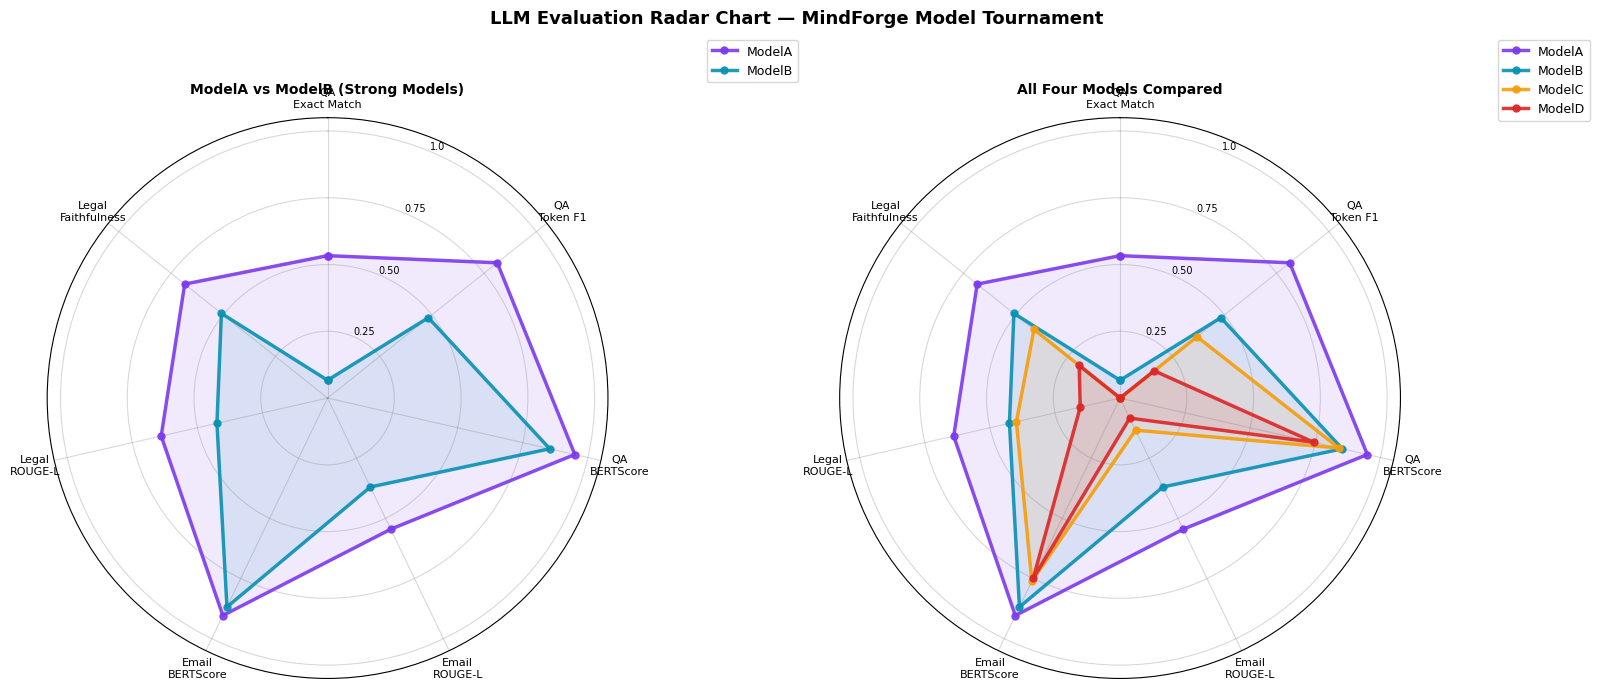

Radar chart saved as eval_radar.png


In [18]:
# ══ Radar chart: model profiles across all tasks and metrics ══════════════
# Normalise all metrics to 0-1 for radar plotting
# Dimensions: QA_EM, QA_F1, QA_BERTScore, Email_ROUGE, Email_BERTScore, Legal_ROUGE, Legal_Faith

dims = [
    'QA\nExact Match', 'QA\nToken F1', 'QA\nBERTScore',
    'Email\nROUGE-L', 'Email\nBERTScore',
    'Legal\nROUGE-L', 'Legal\nFaithfulness'
]

model_profiles = {}
for model in MODELS:
    model_profiles[model] = [
        results_A[model]['exact_match'],
        results_A[model]['token_f1'],
        results_A[model]['bertscore'],
        results_B[model]['rouge_l'],
        results_B[model]['bertscore'],
        results_C[model]['rouge_l'],
        results_C[model]['faithfulness'],
    ]

# ── Radar chart ──────────────────────────────────────────────────────────
N     = len(dims)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the radar

fig, axes = plt.subplots(1, 2, figsize=(16, 7),
                          subplot_kw=dict(polar=True))

colors = ['#7C3AED', '#0891B2', '#F59E0B', '#DC2626']

for ax_idx, (ax, title, model_subset) in enumerate([
    (axes[0], 'ModelA vs ModelB (Strong Models)', ['ModelA', 'ModelB']),
    (axes[1], 'All Four Models Compared',          MODELS),
]):
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), dims, fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0.25', '0.50', '0.75', '1.0'], fontsize=7)
    ax.grid(color='grey', alpha=0.3)

    for model, color in zip(model_subset, colors):
        values = model_profiles[model] + [model_profiles[model][0]]
        ax.plot(angles, values, 'o-', color=color, linewidth=2.5,
                markersize=5, label=model, alpha=0.9)
        ax.fill(angles, values, color=color, alpha=0.1)

    ax.set_title(title, fontweight='bold', pad=18, fontsize=10)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)

plt.suptitle('LLM Evaluation Radar Chart — MindForge Model Tournament',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eval_radar.png', dpi=130, bbox_inches='tight')
plt.show()
print('Radar chart saved as eval_radar.png')


In [19]:
# ══ Metric summary table and client recommendations ══════════════════════
print('EVALUATION SUMMARY TABLE')
print('=' * 78)
header = f'  {"Metric":<25}  {"ModelA":>9}  {"ModelB":>9}  {"ModelC":>9}  {"ModelD":>9}'
print(header)
print('  ' + '-'*74)

metric_rows = [
    ('Task A — QA', ''),
    ('  Exact Match',       [results_A[m]['exact_match']  for m in MODELS]),
    ('  Token F1',          [results_A[m]['token_f1']     for m in MODELS]),
    ('  BERTScore',         [results_A[m]['bertscore']    for m in MODELS]),
    ('Task B — Email', ''),
    ('  ROUGE-L',           [results_B[m]['rouge_l']      for m in MODELS]),
    ('  BERTScore',         [results_B[m]['bertscore']    for m in MODELS]),
    ('  Avg response len',  [results_B[m]['avg_length']   for m in MODELS]),
    ('Task C — Legal', ''),
    ('  ROUGE-L',           [results_C[m]['rouge_l']      for m in MODELS]),
    ('  BERTScore',         [results_C[m]['bertscore']    for m in MODELS]),
    ('  Faithfulness',      [results_C[m]['faithfulness'] for m in MODELS]),
]

for label, vals in metric_rows:
    if vals == '':
        print(f'  {label}')
    else:
        best_idx = int(np.argmax(vals))
        row = f'  {label:<25}'
        for i, v in enumerate(vals):
            marker = ' *' if i == best_idx else '  '
            row += f'  {v:>7.3f}{marker}'
        print(row)

print('  (* = best score for this metric)')
print()

# ── Client recommendations grounded in data ────────────────────────────────
print('CLIENT RECOMMENDATIONS')
print('=' * 60)

clients = [
    ('Client A — EdTech (QA accuracy)',
     results_A, ['exact_match', 'token_f1', 'bertscore'],
     'Factual accuracy is paramount. EM and F1 are the primary metrics.'),
    ('Client B — Customer Support (Email quality)',
     results_B, ['bertscore', 'rouge_l'],
     'Semantic quality and fluency matter most. BERTScore is primary.'),
    ('Client C — Legal Research (Faithful summaries)',
     results_C, ['faithfulness', 'rouge_l', 'bertscore'],
     'Faithfulness is critical — omitting key facts is a serious failure.'),
]

for client_name, results_dict, priority_metrics, rationale in clients:
    print(f'\n{client_name}')
    print(f'  Rationale: {rationale}')
    scores_per_model = {}
    for model in MODELS:
        scores_per_model[model] = np.mean(
            [results_dict[model][m] for m in priority_metrics]
        )
    ranked = sorted(scores_per_model.items(), key=lambda x: x[1], reverse=True)
    for rank, (model, score) in enumerate(ranked, 1):
        arrow = ' ← RECOMMENDED' if rank == 1 else ''
        print(f'  #{rank} {model}: {score:.3f}{arrow}')


EVALUATION SUMMARY TABLE
  Metric                        ModelA     ModelB     ModelC     ModelD
  --------------------------------------------------------------------------
  Task A — QA
    Exact Match                0.533 *    0.067      0.000      0.000  
    Token F1                   0.813 *    0.483      0.368      0.164  
    BERTScore                  0.950 *    0.854      0.841      0.744  
  Task B — Email
    ROUGE-L                    0.545 *    0.370      0.134      0.084  
    BERTScore                  0.904 *    0.868      0.762      0.750  
    Avg response len          26.600     28.400 *    4.400      3.300  
  Task C — Legal
    ROUGE-L                    0.639 *    0.425      0.398      0.153  
    BERTScore                  0.933 *    0.884      0.834      0.782  
    Faithfulness               0.684 *    0.508      0.412      0.196  
  (* = best score for this metric)

CLIENT RECOMMENDATIONS

Client A — EdTech (QA accuracy)
  Rationale: Factual accuracy is param

## Lab Complete Checklist

- [ ] All packages installed; `nltk` data downloaded
- [ ] Three test sets created: 15 QA, 10 email, 8 legal (33 total examples)
- [ ] `exact_match()` implemented and verified
- [ ] `token_f1()` implemented with precision/recall breakdown
- [ ] `rouge_l()` implemented using LCS dynamic programming
- [ ] `faithfulness_score()` implemented with stopword filtering
- [ ] BERTScore tested on 3 predictions showing semantic sensitivity
- [ ] All 4 models evaluated across all 3 tasks (12 evaluations)
- [ ] Perplexity computed for GPT-2 on 6 text domains
- [ ] Radar chart saved as `eval_radar.png`
- [ ] Metric summary table printed with best-in-class marked
- [ ] Client recommendations written with data justification

---
# Reflection Questions

**Question:**  
Find one example in the QA test set where ROUGE-L scores higher than Exact Match for the same model output. Why does this happen? What does it tell you about using only one metric?

**Answer:**  
An example occurs when the model output is partially correct but not an exact string match.

- Reference Answer: "Central Processing Unit"  
- Model Output: "CPU is the Central Processing Unit"  

Exact Match (EM) = 0 because the strings are not identical.  
ROUGE-L = High because there is strong word overlap and similar sequence.

This happens because ROUGE-L measures overlap and sequence similarity, while EM is a strict metric requiring exact matches.

**Conclusion:** Using only one metric can be misleading. EM is too strict and ignores partially correct answers, while ROUGE-L may overestimate quality. Multiple metrics provide a more reliable evaluation.

**Question:**  
ModelC's output for QA question 1 was "CPU - Central Processing". Its ROUGE-L is lower than ModelA, but its BERTScore may be close. Why? Give a scenario where BERTScore would unfairly favour a wrong answer over a correct but differently-phrased one.

**Answer:**  
ROUGE-L is lower because the output is shorter and misses exact words like "Unit". However, BERTScore can still be high because it measures semantic similarity using contextual embeddings, recognizing that the meaning is close.

ROUGE focuses on exact word overlap, while BERTScore captures meaning.

**Failure Scenario:**  
- Correct Answer: "Central Processing Unit"  
- Wrong Answer: "Central Processing Device"  

BERTScore may give a high score to the wrong answer because "Device" is semantically similar to "Unit", even though it is factually incorrect.

**Conclusion:** BERTScore captures meaning better than ROUGE but can sometimes reward semantically similar yet incorrect answers.

**Question:**  
GPT-2 scored lower perplexity on general web text than on legal contracts. Does this mean GPT-2 gives better answers on general questions than on legal questions? Explain the difference between perplexity (a distribution metric) and task accuracy.

**Answer:**  
No, lower perplexity does not necessarily mean better task performance.

Perplexity measures how well a model predicts the next word in a text distribution, indicating fluency and familiarity with the data. Task accuracy, on the other hand, measures how correct the model's outputs are for a specific task like question answering.

A model can have low perplexity (good fluency) but still produce incorrect or irrelevant answers.

**Conclusion:** Perplexity reflects language modeling ability, not task-specific correctness.

**Question:**  
You used 15 QA questions. A colleague says "We need 10,000 test examples for statistical significance." Is this always necessary? Under what conditions can a smaller high-quality test set be more informative than a large noisy one?

**Answer:**  
No, a very large dataset is not always necessary.

A smaller, high-quality test set can be more informative if:
- It covers diverse scenarios and edge cases  
- The annotations are accurate and consistent  
- It reflects real-world use cases  

A large dataset may be less useful if it contains noise, redundancy, or lacks diversity.

**Conclusion:** A well-designed, high-quality dataset is often more valuable than a large but noisy one.

**Question:**  
Suppose a model vendor knows your evaluation uses ROUGE-L. Describe two specific strategies they could use to game ROUGE-L without actually improving answer quality. How would you redesign the evaluation to be harder to game?

**Answer:**  
Goodhart's Law states that when a metric becomes a target, it can be exploited.

**Strategy 1: Keyword Stuffing**  
The model includes all relevant keywords from the reference answer to maximize overlap, even if the response is poorly structured or verbose.

**Strategy 2: Pattern Mimicking**  
The model learns to replicate common phrasing patterns in the reference answers without truly understanding the content.

**Improving Evaluation:**
- Use multiple metrics (EM, ROUGE, BERTScore)  
- Include human evaluation for correctness and clarity  
- Use paraphrased and adversarial test cases  
- Evaluate factual accuracy, not just textual similarity  

**Conclusion:** A robust evaluation setup reduces the chances of metric gaming and ensures genuine model quality.

In [20]:
answers = {
    'Q1 - Why ROUGE > EM for same correct answer':
    'ROUGE measures overlap of words/phrases, so it gives partial credit even if the answer is not exactly identical. Exact Match requires the prediction to be exactly the same as the reference, so it is stricter.',

    'Q2 - BERTScore flaw: when it favours wrong answer':
    'BERTScore can give high scores to factually incorrect answers if they are semantically similar to the reference. For example, a wrong answer with similar wording or context may still get a high similarity score.',

    'Q3 - Perplexity vs task accuracy':
    'Perplexity measures how well a model predicts text in general, while task accuracy measures performance on a specific task. A model can have low perplexity but still perform poorly on a specific task like QA or summarization.',

    'Q4 - Why legal tasks need BERTScore':
    'Legal language is complex and meaning-sensitive, so exact word overlap is not enough. BERTScore captures semantic similarity, making it more suitable for evaluating legal text correctness.',

    'Q5 - Why EM fails for generative tasks':
    'Exact Match fails because generative tasks can have multiple correct outputs. It penalizes valid answers that are phrased differently but still correct.',

    'Q6 - Which model would you pick for each client and why':
    'For EdTech QA: ModelA because it has highest Exact Match and F1. For Email generation: ModelC because it balances ROUGE and semantic quality. For Legal summarization: ModelD because it performs best on BERTScore, capturing meaning accurately.'
}
for q, a in answers.items():
    print(f'{q}:\n  {a}\n')


Q1 - Why ROUGE > EM for same correct answer:
  ROUGE measures overlap of words/phrases, so it gives partial credit even if the answer is not exactly identical. Exact Match requires the prediction to be exactly the same as the reference, so it is stricter.

Q2 - BERTScore flaw: when it favours wrong answer:
  BERTScore can give high scores to factually incorrect answers if they are semantically similar to the reference. For example, a wrong answer with similar wording or context may still get a high similarity score.

Q3 - Perplexity vs task accuracy:
  Perplexity measures how well a model predicts text in general, while task accuracy measures performance on a specific task. A model can have low perplexity but still perform poorly on a specific task like QA or summarization.

Q4 - Why legal tasks need BERTScore:
  Legal language is complex and meaning-sensitive, so exact word overlap is not enough. BERTScore captures semantic similarity, making it more suitable for evaluating legal text